### What Partial Derivatives are?

In [12]:
import numpy as np
import torch
import math # for constant pi
import matplotlib.pyplot as plt

#### Gradients Applied at Machine Learning
Define a function $f(x, y)$ for $z = x^2 - y^2$: 

In [56]:
def f(x,y):
    return x**2 - y**2

Plot $z$ with respect to $x$ by varying $x$... 

In [11]:
xs = np.linspace(-3,3,100)

In [13]:
zs_wrt_x = f(xs,0)

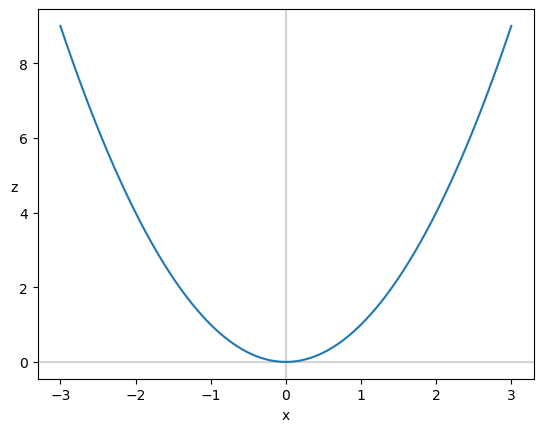

In [17]:
fig, ax = plt.subplots()
plt.axvline(x=0,color='lightgray')
plt.axhline(y=0,color='lightgray')
plt.xlabel('x')
plt.ylabel('z',rotation=0)
_=ax.plot(xs,zs_wrt_x)


To determine the slope of $z$ w.r.t. $x$ at a given point along the curve, we can use the partial derivative from the slides: $$ \frac{\partial z}{\partial x} = 2x$$

In [18]:
def delz_delx(x,y):
    return 2*x

In [19]:
x_samples = [-2,-1,0,1,2]

In [20]:
colors = ['red','orange','green','blue','purple']

In [27]:
def point_and_tangent_wrt_x(xs,x,y,f,fprime,color):
    z = f(x,y)
    plt.scatter(x,y,c=color,zorder=3)

    tangent_m  = fprime(x,y)
    tangent_b = z - tangent_m*x
    tangent_line = tangent_m*xs+tangent_b

    plt.plot(xs,tangent_line, c=color,linestyle='dashed',zorder=3)

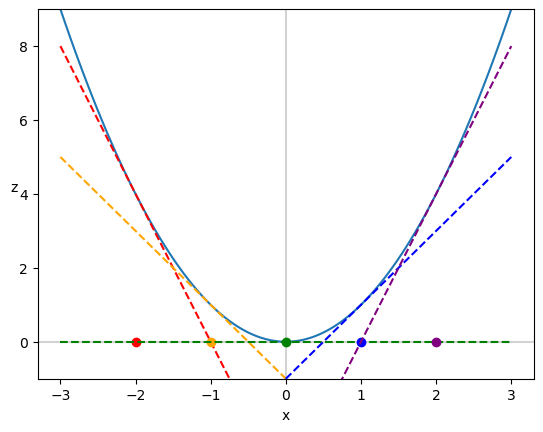

In [29]:
fig,ax = plt.subplots()
plt.axvline(x=0,color='lightgray')
plt.axhline(y=0,color='lightgray')

for i,x in enumerate(x_samples):
    point_and_tangent_wrt_x(xs, x, 0, f, delz_delx, colors[i])

plt.ylim(-1,9)
plt.xlabel('x')
plt.ylabel('z',rotation=0)
_=ax.plot(xs,zs_wrt_x)

Now let's plot $z$ with respect to $y$ by varying $y$...

In [32]:
ys = np.linspace(-3,3,100)

...while holding $x$ constant (e.g., at $x$ = 0): 

In [33]:
zs_wrt_y = f(0,ys)

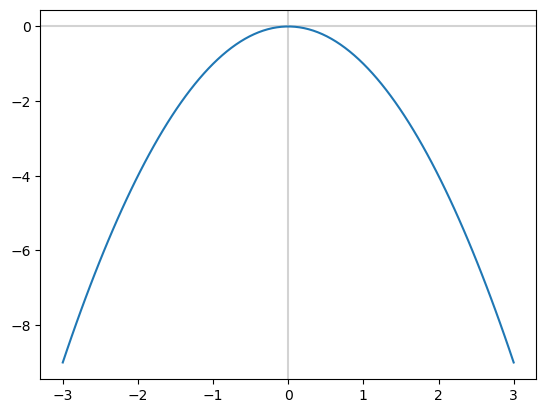

In [37]:
fig, ax = plt.subplots()
plt.axvline(x=0,color='lightgray')
plt.axhline(y=0,color='lightgray')
_=ax.plot(ys,zs_wrt_y)

So for example, holding $x$ constant at 2 instead of 0 increases $z$, but has no impact whatsoever on the slope of $z$ w.r.t. $y$: 

In [38]:
zs_wrt_y = f(2,ys)

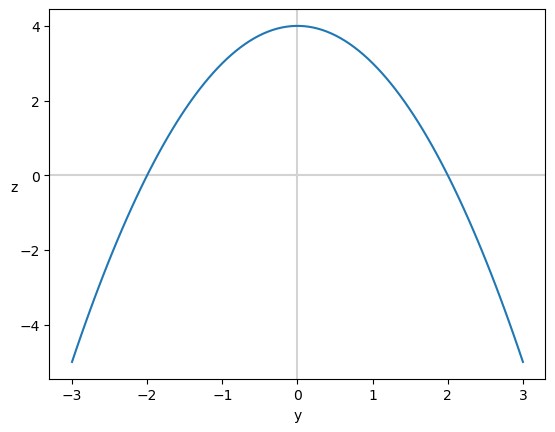

In [42]:
fig, ax = plt.subplots()
plt.axvline(x=0,color='lightgray')
plt.axhline(y=0,color='lightgray')
plt.xlabel('y')
plt.ylabel('z',rotation=0)
_=plt.plot(ys,zs_wrt_y)

In [54]:
def delz_dely(x,y):
    return -2*y

In [53]:
y_samples=[-2,-1,0,1,2]

In [62]:
def point_and_tangent_wrt_y(ys,x,y,f,fprime,color):
    z = f(x,y)
    plt.scatter(y,z,color=color,zorder=3)

    tangent_m = fprime(x,y)
    tangent_b = z - tangent_m*y
    tangent_line = tangent_m*ys + tangent_b

    plt.plot(ys,tangent_line,c=color,linestyle='dashed',zorder=3)

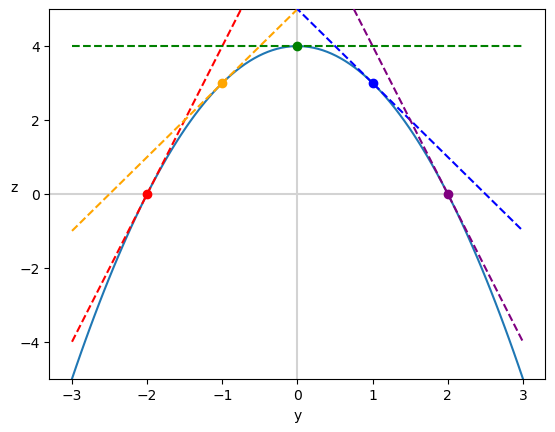

In [63]:
fig, ax = plt.subplots()
plt.axvline(x=0,color='lightgray')
plt.axhline(y=0,color='lightgray')

for i, y in enumerate(y_samples):
    point_and_tangent_wrt_y(ys,2,y,f,delz_dely,colors[i])

plt.ylim(-5,5)
plt.xlabel('y')
plt.ylabel('z',rotation=0)
_=ax.plot(xs,zs_wrt_y)

#### Calculate Partial Derivative using AutoDiff

In [68]:
x = torch.tensor(0.).requires_grad_()
x

tensor(0., requires_grad=True)

In [70]:
y = torch.tensor(0.).requires_grad_()
y

tensor(0., requires_grad=True)

In [71]:
z = f(x,y)
z

tensor(0., grad_fn=<SubBackward0>)

In [75]:
z.backward(retain_graph=True) #AutoDiff

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

As we already knew the slope of point(0,0,0) is zero with respect to both x and y axes:

In [77]:
x.grad

tensor(0.)

In [79]:
y.grad

tensor(-0.)

### Partial Derivative of Cylinder's Volume
The volume of a cylinder is described by $v = \pi r^2 l$ where: 

* $r$ is the radius of the cylinder
* $l$ is its length

In [80]:
def cylinder_volume(r,l):
    return math.pi*(r**2)*l

In [82]:
r = torch.tensor(3.).requires_grad_()
r

tensor(3., requires_grad=True)

In [83]:
l = torch.tensor(5.).requires_grad_()
l

tensor(5., requires_grad=True)

In [84]:
v = cylinder_volume(r,l)
v

tensor(141.3717, grad_fn=<MulBackward0>)

In [85]:
v.backward()

In [92]:
l.grad #partial derivative w.r.t l

tensor(28.2743)

We will derived manualling to verify AutoDiff using formula: $$\frac{\partial v}{\partial l} = \pi r^2$$

In [89]:
math.pi*r**2

tensor(28.2743, grad_fn=<MulBackward0>)

##### This means that at r=3, the change in l by one unit corresponds to a change in v of 28.2743...

In [94]:
cylinder_volume(3,5)

141.3716694115407

In [97]:
cylinder_volume(3,6) - cylinder_volume(3,5)

28.274333882308127

In [98]:
cylinder_volume(3,7)-cylinder_volume(3,6)

28.274333882308156

For changes in $v$ with respect to $r$ we have the following from the slides: $$\frac{\partial v}{\partial r} = 2 \pi r l$$

In [100]:
r.grad #partial derivative w.r.t r

tensor(94.2478)

We will derived manualling to verify AutoDiff using above formula

In [101]:
2 * math.pi * r * l

tensor(94.2478, grad_fn=<MulBackward0>)

$r$ is included in the partial derivative so adjusting it affects the scale of its impact on $v$. Although it's our first example in this notebook, it is typical in calculus for the derivative only to apply at an infinitesimally small $\Delta r$. The smaller the $\Delta r$, the closer to the true $\frac{\partial v}{\partial r}$. E.g., at $\Delta r = 1 \times 10^{-6}$:

In [102]:
delta = 1e-6

In [103]:
(cylinder_volume(3+delta,5) - cylinder_volume(3,5))/delta

94.24779531741478